In [ ]:
# =========================
# CELL 1: Install / import libraries (Gemma-3-1B-IT QLoRA)
# =========================

!pip -q install -U "transformers>=4.46.0" "datasets>=2.19.0" "accelerate>=0.30.1" \
                   "peft>=0.11.1" "bitsandbytes>=0.43.1" "safetensors>=0.4.3"

import os, torch, pandas as pd
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForCausalLM,
    TrainingArguments, Trainer, default_data_collator,
    BitsAndBytesConfig
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, PeftModel
from google.colab import drive

drive.mount("/content/drive")

TRAIN_PATH  = "/content/drive/MyDrive/Thesis/FineTunning/oral_cancer_train.csv"
TEST_PATH   = "/content/drive/MyDrive/Thesis/FineTunning/oral_cancer_test.csv"

OUT_DIR     = "/content/drive/MyDrive/Thesis/FineTunning/gemma31b_out_lbl"
ADAPTER_DIR = "/content/drive/MyDrive/Thesis/FineTunning/gemma31b_lora_adapter_lbl"

MODEL_ID = "google/gemma-3-1b-it"
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 127.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 520.7/520.7 kB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 49.5 MB/s eta 0:00:00
Mounted at /content/drive
Device: cuda


In [ ]:
# =========================
# CELL 2: Fine-tune (QLoRA) + Oversample minority
# Targets: EXACTLY "Radiotherapy" or "No radiation"
# =========================

df = pd.read_csv(TRAIN_PATH)
df.columns = df.columns.str.strip()
print("Train shape:", df.shape)

def normalize_label(x):
    s = str(x).strip().lower()
    if s == "radiotherapy":
        return "Radiotherapy"
    if s == "no radiation":
        return "No radiation"
    return "No radiation"

# ---- Oversample minority class ----
tmp = df.copy()
tmp["label"] = tmp["Radiotherapy"].apply(normalize_label)

print("\nLabel counts (before):\n", tmp["label"].value_counts())

df_no  = tmp[tmp["label"] == "No radiation"].copy()
df_yes = tmp[tmp["label"] == "Radiotherapy"].copy()
if len(df_yes) == 0 or len(df_no) == 0:
    raise ValueError("One class is empty after normalization. Check Radiotherapy column values.")

df_yes_up = df_yes.sample(n=len(df_no), replace=True, random_state=42)
tmp_balanced = pd.concat([df_no, df_yes_up], ignore_index=True).sample(frac=1, random_state=42)

print("\nLabel counts (after):\n", tmp_balanced["label"].value_counts())

df_bal = tmp_balanced.drop(columns=["label"])

# ---- Prompt ----
def make_prompt(row):
    return f"""Decide the radiotherapy outcome.
Age: {row["Age"]}
Sex: {row["Sex"]}
MaritalStatus: {row["Marital status at diagnosis"]}
PrimarySite: {row["Primary Site - labeled"]}
Grade: {row["Grade"]}
TNM: {row["T stage"]} {row["N stage"]} {row["M stage"]}

Answer with exactly one of:
Radiotherapy
No radiation

Answer:
""".strip()

def make_target(row):
    return normalize_label(row["Radiotherapy"])

rows = [{"prompt": make_prompt(df_bal.iloc[i]), "target": make_target(df_bal.iloc[i])}
        for i in range(len(df_bal))]
dataset = Dataset.from_list(rows)
print(dataset)

# ---- Tokenizer ----
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# ---- 4-bit base ----
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
)

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    low_cpu_mem_usage=True,
    trust_remote_code=True
)
base_model.config.use_cache = False
base_model = prepare_model_for_kbit_training(base_model)

# ---- LoRA (Gemma uses standard proj names; these usually exist) ----
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj","k_proj","v_proj","o_proj","up_proj","down_proj","gate_proj"]
)

model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()

# ---- Tokenize + mask ----
MAX_LEN = 256

def tokenize_and_mask(ex):
    prompt = ex["prompt"]
    target = ex["target"]
    full = prompt + "\n" + target

    enc = tokenizer(
        full,
        truncation=True,
        max_length=MAX_LEN,
        padding="max_length",
        return_attention_mask=True
    )

    prompt_ids = tokenizer(
        prompt,
        truncation=True,
        max_length=MAX_LEN,
        add_special_tokens=True
    )["input_ids"]

    prompt_len = min(len(prompt_ids), MAX_LEN)

    labels = enc["input_ids"].copy()
    labels[:prompt_len] = [-100] * prompt_len
    labels = [(-100 if enc["attention_mask"][i] == 0 else labels[i]) for i in range(MAX_LEN)]
    enc["labels"] = labels
    return enc

tokenized = dataset.map(tokenize_and_mask, remove_columns=dataset.column_names)

# ---- Train ----
args = TrainingArguments(
    output_dir=OUT_DIR,
    per_device_train_batch_size=4,     # Gemma 1B is small; you can increase if you want
    gradient_accumulation_steps=8,
    num_train_epochs=1,
    learning_rate=5e-5,
    bf16=False,
    fp16=torch.cuda.is_available(),
    logging_steps=25,
    save_steps=200,
    save_total_limit=2,
    report_to="none",
    optim="paged_adamw_8bit",
    max_grad_norm=1.0,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tokenized,
    data_collator=default_data_collator
)

trainer.train()

model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)
print("Adapter saved:", ADAPTER_DIR)

Train shape: (7551, 13)

Label counts (before):
 label
No radiation    5890
Radiotherapy    1661
Name: count, dtype: int64

Label counts (after):
 label
Radiotherapy    5890
No radiation    5890
Name: count, dtype: int64
Dataset({
    features: ['prompt', 'target'],
    num_rows: 11780
})


config.json:   0%|          | 0.00/899 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

...

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss
25,1.761577
50,0.355436
75,0.207123
100,0.176133
125,0.177525
150,0.183583
175,0.170769
200,0.171609
225,0.172251


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss
25,1.761577
50,0.355436
75,0.207123
100,0.176133
125,0.177525
150,0.183583
175,0.170769
200,0.171609
225,0.172251
250,0.169304


Adapter saved: /content/drive/MyDrive/Thesis/FineTunning/gemma31b_lora_adapter_lbl


In [ ]:
# =========================
# GEMMA - Save training logs to Google Drive
# =========================

import json

LOG_PATH = "/content/drive/MyDrive/Thesis/FineTunning/gemma_training_logs.json"

training_logs = trainer.state.log_history

print("Total log records:", len(training_logs))

with open(LOG_PATH, "w") as f:
    json.dump(training_logs, f)

print("Training logs saved to:")
print(LOG_PATH)

    step      loss
0     25  1.761577
1     50  0.355436
2     75  0.207123
3    100  0.176133
4    125  0.177525
5    150  0.183583
6    175  0.170769
7    200  0.171609
8    225  0.172251
9    250  0.169304
10   275  0.166844
11   300  0.166770
12   325  0.165860
13   350  0.166514


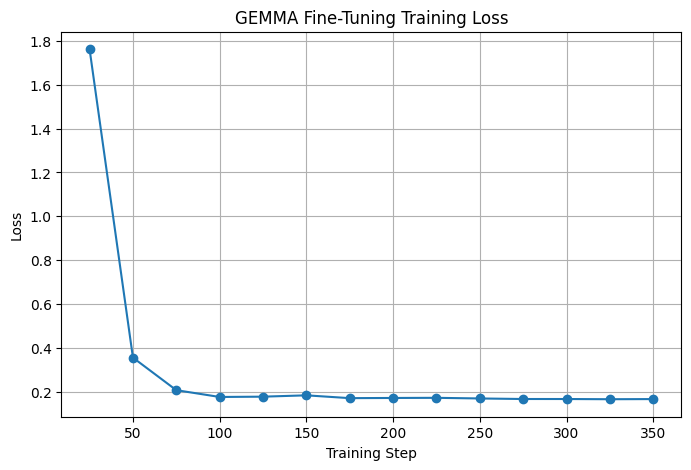

In [ ]:
# =========================
# GEMMA - Training Loss Visualization
# =========================

import json
import pandas as pd
import matplotlib.pyplot as plt

LOG_PATH = "/content/drive/MyDrive/Thesis/FineTunning/gemma_training_logs.json"

with open(LOG_PATH, "r") as f:
    training_logs = json.load(f)

log_df = pd.DataFrame(training_logs)
loss_df = log_df[log_df["loss"].notna()].copy()

if loss_df.empty:
    print("No loss values found in training logs.")
else:
    print(loss_df[["step", "loss"]])

    plt.figure(figsize=(8, 5))
    plt.plot(loss_df["step"], loss_df["loss"], marker="o")
    plt.xlabel("Training Step")
    plt.ylabel("Loss")
    plt.title("GEMMA Fine-Tuning Training Loss")
    plt.grid(True)
    plt.show()

    step      loss
0     25  1.761577
1     50  0.355436
2     75  0.207123
3    100  0.176133
4    125  0.177525
5    150  0.183583
6    175  0.170769
7    200  0.171609
8    225  0.172251
9    250  0.169304
10   275  0.166844
11   300  0.166770
12   325  0.165860
13   350  0.166514


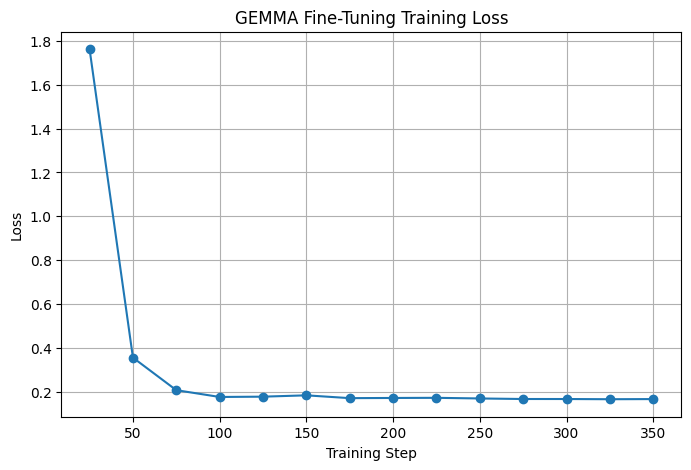

In [ ]:
# =========================
# GEMMA - Training Loss Visualization
# =========================

import json
import pandas as pd
import matplotlib.pyplot as plt

LOG_PATH = "/content/drive/MyDrive/Thesis/FineTunning/gemma_training_logs.json"

with open(LOG_PATH, "r") as f:
    training_logs = json.load(f)

log_df = pd.DataFrame(training_logs)
loss_df = log_df[log_df["loss"].notna()].copy()

if loss_df.empty:
    print("No loss values found in training logs.")
else:
    print(loss_df[["step", "loss"]])

    plt.figure(figsize=(8, 5))
    plt.plot(loss_df["step"], loss_df["loss"], marker="o")
    plt.xlabel("Training Step")
    plt.ylabel("Loss")
    plt.title("GEMMA Fine-Tuning Training Loss")
    plt.grid(True)
    plt.show()

In [ ]:
# =========================
# CELL 3: Inference (STRICT 2 OPTIONS) + Save CSV
# Output ONLY: "Radiotherapy" or "No radiation"
# =========================

import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel

record_from = 21
record_to   = 35
SAVE_PATH = f"/content/drive/MyDrive/Thesis/FineTunning/GEMMA31B_only2_{record_from}_{record_to}.csv"

test_df = pd.read_csv(TEST_PATH)
test_df.columns = test_df.columns.str.strip()
subset = test_df.iloc[record_from-1:record_to].copy().reset_index(drop=True)
print("Selected rows:", len(subset))

tokenizer = AutoTokenizer.from_pretrained(ADAPTER_DIR, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

bnb_config = BitsAndBytesConfig(load_in_4bit=True)
base = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    low_cpu_mem_usage=True,
    trust_remote_code=True
)
base.config.use_cache = False
base.eval()

model = PeftModel.from_pretrained(base, ADAPTER_DIR)
model.eval()

MAX_LEN = 256

def make_prompt(row):
    return f"""Decide the radiotherapy outcome.

Age: {row["Age"]}
Sex: {row["Sex"]}
MaritalStatus: {row["Marital status at diagnosis"]}
PrimarySite: {row["Primary Site - labeled"]}
Grade: {row["Grade"]}
TNM: {row["T stage"]} {row["N stage"]} {row["M stage"]}

Answer with exactly one of:
Radiotherapy
No radiation

Answer:
""".strip()

# ---- Constrained decoding (only 2 labels) ----
LABELS = ["Radiotherapy", "No radiation"]

def build_label_token_ids(tok, labels):
    seqs = []
    for lab in labels:
        for variant in [lab, " " + lab]:
            ids = tok(variant, add_special_tokens=False)["input_ids"]
            if ids:
                seqs.append(ids)
    uniq, seen = [], set()
    for s in seqs:
        t = tuple(s)
        if t not in seen:
            uniq.append(s)
            seen.add(t)
    return uniq

label_token_seqs = build_label_token_ids(tokenizer, LABELS)

def make_prefix_allowed_fn(prompt_len):
    eos = tokenizer.eos_token_id

    def prefix_allowed_tokens_fn(batch_id, input_ids):
        if input_ids.dim() == 1:
            seq = input_ids
        else:
            seq = input_ids[batch_id]

        gen = seq[prompt_len:].tolist()

        if len(gen) == 0:
            return sorted({seq_ids[0] for seq_ids in label_token_seqs})

        allowed = set()
        complete = False

        for seq_ids in label_token_seqs:
            if gen == seq_ids:
                complete = True
                continue
            if len(gen) < len(seq_ids) and gen == seq_ids[:len(gen)]:
                allowed.add(seq_ids[len(gen)])

        if complete and not allowed:
            return [eos]

        return list(allowed) if allowed else [eos]

    return prefix_allowed_tokens_fn

def predict_label(prompt):
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=MAX_LEN).to(model.device)
    prompt_len = inputs["input_ids"].shape[1]
    prefix_fn = make_prefix_allowed_fn(prompt_len)

    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=6,
            do_sample=False,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id,
            prefix_allowed_tokens_fn=prefix_fn
        )

    gen = out[0, prompt_len:]
    return tokenizer.decode(gen, skip_special_tokens=True).strip()

preds = []
for i in range(len(subset)):
    pred = predict_label(make_prompt(subset.iloc[i]))
    preds.append(pred)
    print(f"Record {record_from+i}: {pred}")

out_df = subset.copy()
out_df.insert(0, "RecordNo", list(range(record_from, record_to + 1)))
out_df = out_df.rename(columns={"Radiotherapy": "Control_Radiotherapy"})
out_df["Predicted_Radiotherapy"] = preds
out_df.to_csv(SAVE_PATH, index=False)
print("Saved:", SAVE_PATH)

Selected rows: 15


Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Record 21: Radiotherapy
Record 22: Radiotherapy
Record 23: Radiotherapy
Record 24: Radiotherapy
Record 25: Radiotherapy
Record 26: Radiotherapy
Record 27: Radiotherapy
Record 28: Radiotherapy
Record 29: Radiotherapy
Record 30: Radiotherapy
Record 31: Radiotherapy
Record 32: Radiotherapy
Record 33: Radiotherapy
Record 34: Radiotherapy
Record 35: Radiotherapy
Saved: /content/drive/MyDrive/Thesis/FineTunning/GEMMA31B_only2_21_35.csv


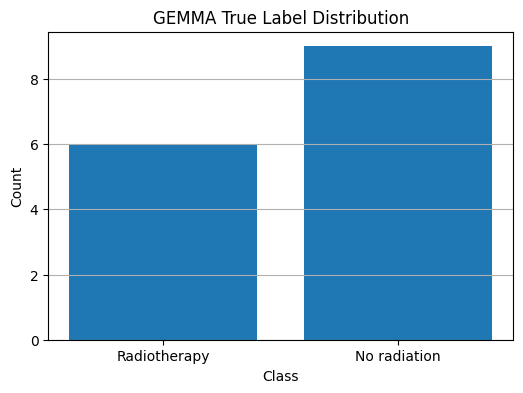

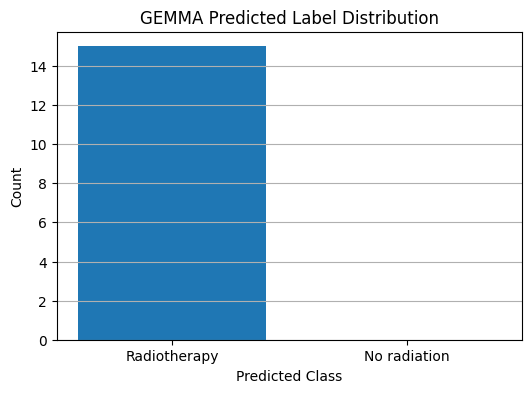

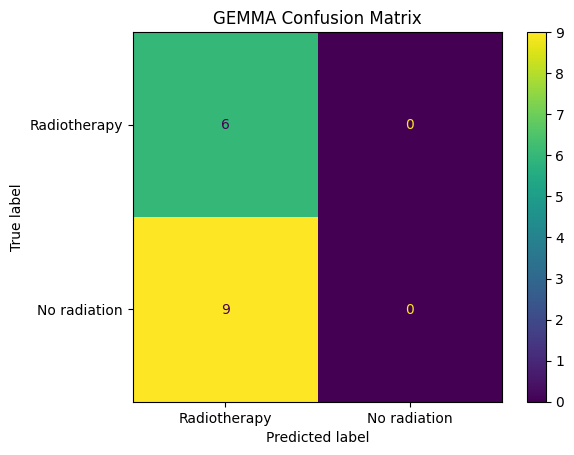


Classification Report:

              precision    recall  f1-score   support

Radiotherapy       0.40      1.00      0.57         6
No radiation       0.00      0.00      0.00         9

    accuracy                           0.40        15
   macro avg       0.20      0.50      0.29        15
weighted avg       0.16      0.40      0.23        15



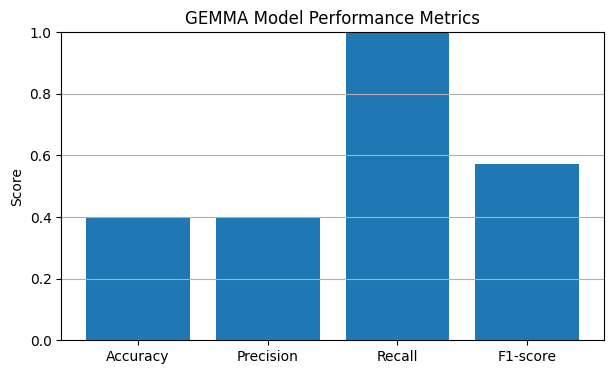

Accuracy : 0.4
Precision: 0.4
Recall   : 1.0
F1-score : 0.5714

Prediction Details:

    RecordNo        Actual     Predicted  Correct
0         21  No radiation  Radiotherapy    False
1         22  Radiotherapy  Radiotherapy     True
2         23  No radiation  Radiotherapy    False
3         24  No radiation  Radiotherapy    False
4         25  Radiotherapy  Radiotherapy     True
5         26  No radiation  Radiotherapy    False
6         27  Radiotherapy  Radiotherapy     True
7         28  No radiation  Radiotherapy    False
8         29  No radiation  Radiotherapy    False
9         30  Radiotherapy  Radiotherapy     True
10        31  Radiotherapy  Radiotherapy     True
11        32  No radiation  Radiotherapy    False
12        33  No radiation  Radiotherapy    False
13        34  No radiation  Radiotherapy    False
14        35  Radiotherapy  Radiotherapy     True


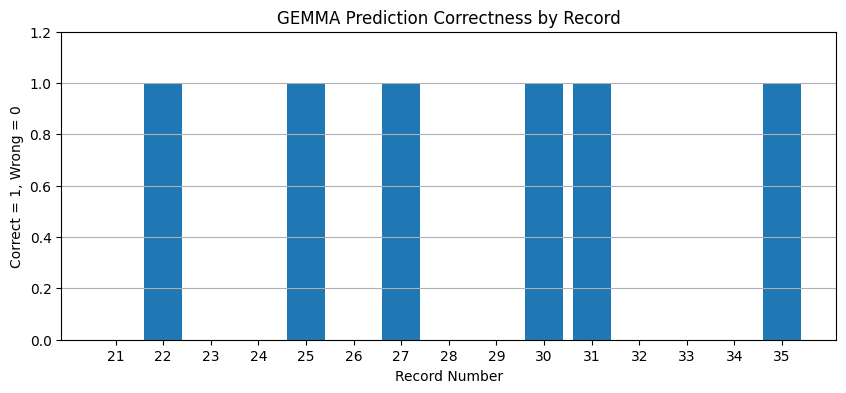

In [ ]:
# =========================
# GEMMA - Evaluation Visualizations
# =========================

import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Normalize labels
def normalize_label(x):
    s = str(x).strip().lower()
    if s == "radiotherapy":
        return "Radiotherapy"
    if s == "no radiation":
        return "No radiation"
    return str(x).strip()

y_true = out_df["Control_Radiotherapy"].apply(normalize_label)
y_pred = out_df["Predicted_Radiotherapy"].apply(normalize_label)

labels = ["Radiotherapy", "No radiation"]

# 1. True label distribution
true_counts = y_true.value_counts().reindex(labels, fill_value=0)

plt.figure(figsize=(6, 4))
plt.bar(true_counts.index, true_counts.values)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("GEMMA True Label Distribution")
plt.grid(axis="y")
plt.show()

# 2. Predicted label distribution
pred_counts = y_pred.value_counts().reindex(labels, fill_value=0)

plt.figure(figsize=(6, 4))
plt.bar(pred_counts.index, pred_counts.values)
plt.xlabel("Predicted Class")
plt.ylabel("Count")
plt.title("GEMMA Predicted Label Distribution")
plt.grid(axis="y")
plt.show()

# 3. Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(values_format="d")
plt.title("GEMMA Confusion Matrix")
plt.show()

# 4. Metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, pos_label="Radiotherapy", zero_division=0)
recall = recall_score(y_true, y_pred, pos_label="Radiotherapy", zero_division=0)
f1 = f1_score(y_true, y_pred, pos_label="Radiotherapy", zero_division=0)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, labels=labels, zero_division=0))

metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1
}

plt.figure(figsize=(7, 4))
plt.bar(metrics.keys(), metrics.values())
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("GEMMA Model Performance Metrics")
plt.grid(axis="y")
plt.show()

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-score :", round(f1, 4))

# 5. Record-wise correctness
result_df = out_df[["RecordNo"]].copy()
result_df["Actual"] = y_true
result_df["Predicted"] = y_pred
result_df["Correct"] = result_df["Actual"] == result_df["Predicted"]

print("\nPrediction Details:\n")
print(result_df)

plt.figure(figsize=(10, 4))
plt.bar(result_df["RecordNo"].astype(str), result_df["Correct"].astype(int))
plt.xlabel("Record Number")
plt.ylabel("Correct = 1, Wrong = 0")
plt.title("GEMMA Prediction Correctness by Record")
plt.ylim(0, 1.2)
plt.grid(axis="y")
plt.show()